<h1 style="color:rgb(255, 98, 0);">1. WikiPedia Retriever</h1>

![Screenshot 2025-04-23 at 6.34.18 PM.png](<attachment:Screenshot 2025-04-23 at 6.34.18 PM.png>)
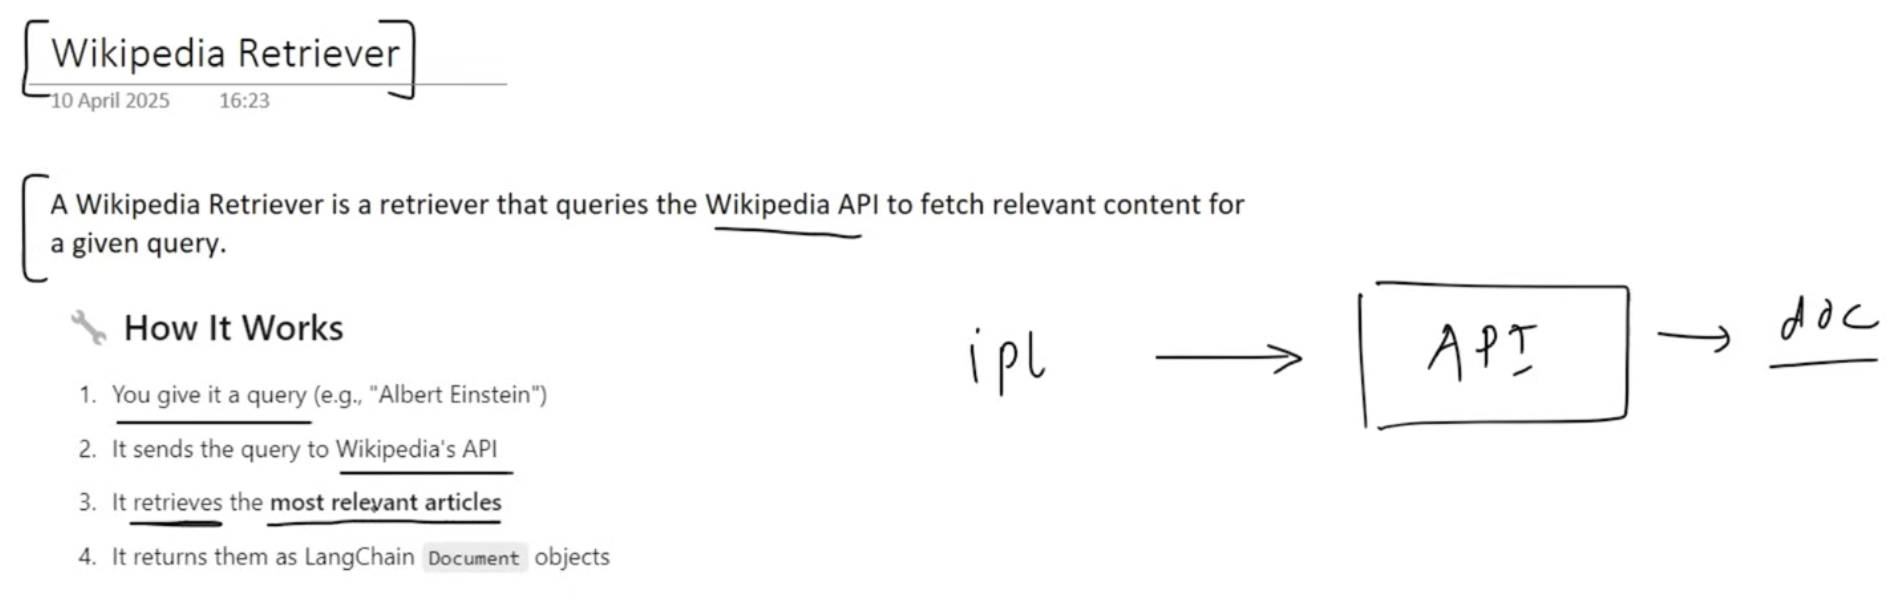

In [1]:
%pip install faiss-cpu wikipedia

  Preparing metadata (setup.py) ... done
  Created wheel for wikipedia: filename=wikipedia-1.4.0-py3-none-any.whl size=11678 sha256=64239dd00891e75a2b71f366f0143cff8993d295441129a05f115872668fd7da
  Stored in directory: /Users/sanghvi/Library/Caches/pip/wheels/63/47/7c/a9688349aa74d228ce0a9023229c6c0ac52ca2a40fe87679b8
Successfully built wikipedia
Note: you may need to restart the kernel to use updated packages.


In [2]:
from langchain_community.retrievers import WikipediaRetriever

In [4]:
# Initialize the retriever (optional: set language and top_k)
retriever = WikipediaRetriever(top_k_results=2, lang="en")

In [9]:
# Define your query
query = "Virat Kohli vs MS Dhoni"

# Get relevant Wikipedia documents
docs = retriever.invoke(query)

In [10]:
# Print retrieved content
for i, doc in enumerate(docs):
    print(f"\n--- Result {i+1} ---")
    print(f"Content:\n{doc.page_content}...")  # truncate for display


--- Result 1 ---
Content:
Virat Kohli's senior career began when he made his debut in List A cricket, playing against Services in the Ranji One-Day Trophy, but he did not have the opportunity to bat during the match. On the international stage, he has been representing India since he was included in the ODl squad for the tour of Sri Lanka.

Kohli was part of the team during India won the 2011 Cricket World Cup, the 2013 ICC Champions Trophy and the 2024 ICC T20 World Cup alongside several Asia Cups. He had previously led his side to the 2008 Under-19 Cricket World Cup title. In league cricket, Kohli has played for the Royal Challengers Bengaluru since the inception of the team in 2008.


== Youth and domestic career ==


=== Delhi ===
Kohli's junior cricket career kicked off in October 2002 at the Luhnu cricket ground in a match against the host state of Himachal Pradesh. In his debut match, Kohli managed to score a total of fifteen runs. His first half-century in national cricket cam

<h1 style="color:rgb(255, 98, 0);">2. Vector Store Retriever</h1>

![Screenshot 2025-04-23 at 6.49.59 PM.png](<attachment:Screenshot 2025-04-23 at 6.49.59 PM.png>)
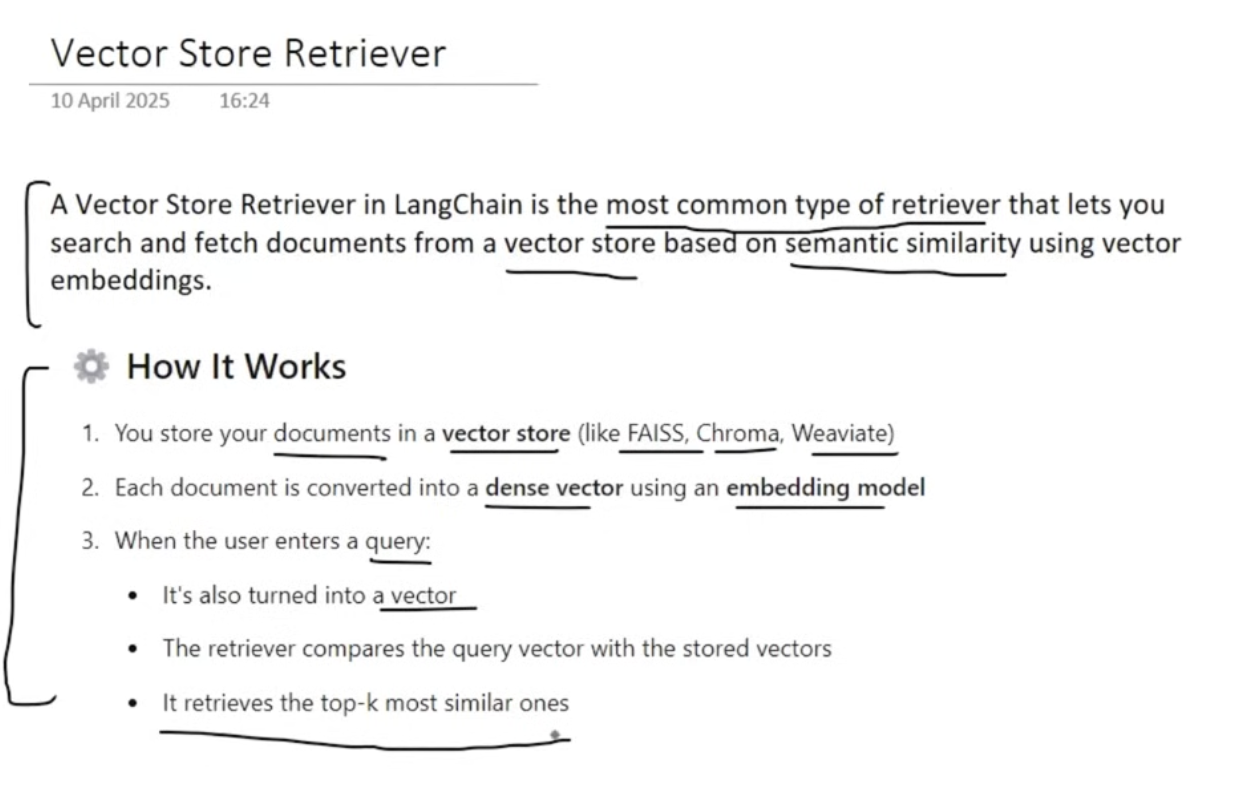

In [14]:
from langchain.embeddings import HuggingFaceEmbeddings
from langchain.vectorstores import Chroma

In [12]:
# Step 1: Your source documents
documents = [
    Document(page_content="LangChain helps developers build LLM applications easily."),
    Document(page_content="Chroma is a vector database optimized for LLM-based search."),
    Document(page_content="Embeddings convert text into high-dimensional vectors."),
    Document(page_content="OpenAI provides powerful embedding models."),
]

In [15]:
# Step 2: Initialize embedding model
embedding_model = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

# Step 3: Create Chroma vector store in memory
vectorstore = Chroma.from_documents(
    documents=documents,
    embedding=embedding_model,
    collection_name="my_collection"
)

In [16]:
# Step 4: Convert vectorstore into a retriever
retriever = vectorstore.as_retriever(search_kwargs={"k": 2})

In [17]:
query = "What is Chroma used for?"
results = retriever.invoke(query)

In [18]:
for i, doc in enumerate(results):
    print(f"\n--- Result {i+1} ---")
    print(doc.page_content)


--- Result 1 ---
Chroma is a vector database optimized for LLM-based search.

--- Result 2 ---
LangChain helps developers build LLM applications easily.


<h1 style="color:rgb(255, 98, 0);">3. MRR</h1>

![Screenshot 2025-04-23 at 7.46.21 PM.png](<attachment:Screenshot 2025-04-23 at 7.46.21 PM.png>)
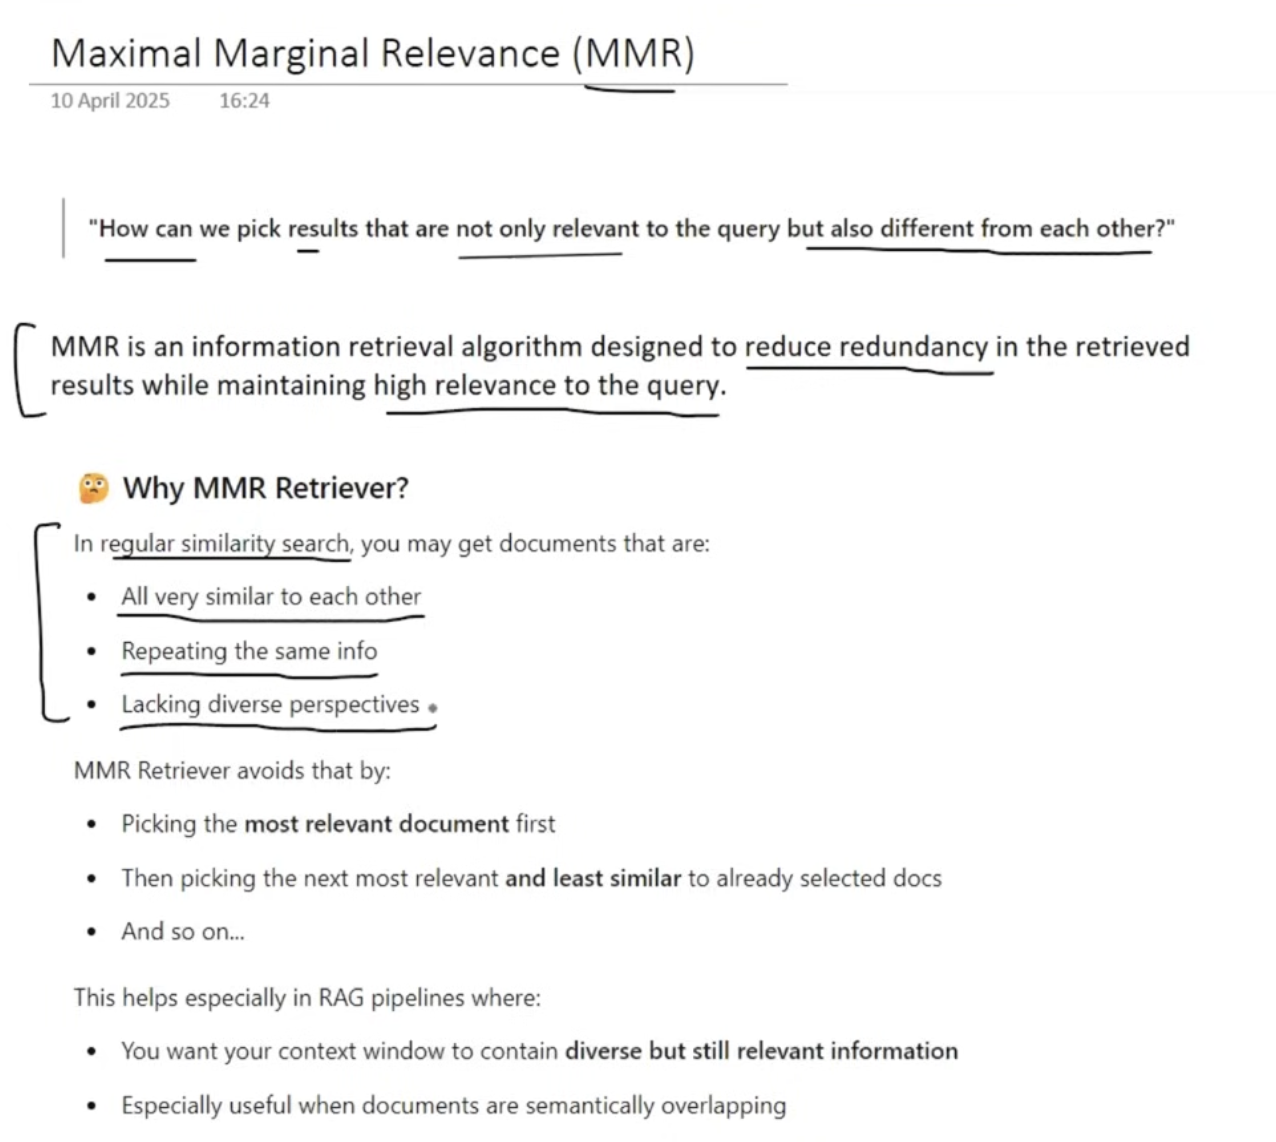

In [19]:
# Sample documents
docs = [
    Document(page_content="LangChain makes it easy to work with LLMs."),
    Document(page_content="LangChain is used to build LLM based applications."),
    Document(page_content="Chroma is used to store and search document embeddings."),
    Document(page_content="Embeddings are vector representations of text."),
    Document(page_content="MMR helps you get diverse results when doing similarity search."),
    Document(page_content="LangChain supports Chroma, FAISS, Pinecone, and more."),
]

In [ ]:
from langchain_community.vectorstores import FAISS

# Initialize embeddings
embedding_model = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

# Step 2: Create the FAISS vector store from documents
vectorstore = FAISS.from_documents(
    documents=docs,
    embedding=embedding_model
)

In [21]:
# Enable MMR in the retriever
retriever = vectorstore.as_retriever(
    search_type="mmr",                   # <-- This enables MMR
    search_kwargs={"k": 3, "lambda_mult": 0.5}  # k = top results, lambda_mult = relevance-diversity balance
)

In [22]:
query = "What is langchain?"
results = retriever.invoke(query)

In [23]:
for i, doc in enumerate(results):
    print(f"\n--- Result {i+1} ---")
    print(doc.page_content)


--- Result 1 ---
LangChain supports Chroma, FAISS, Pinecone, and more.

--- Result 2 ---
LangChain is used to build LLM based applications.

--- Result 3 ---
Embeddings are vector representations of text.


<h1 style="color:rgb(255, 98, 0);">4. Multiquery Retriever</h1>

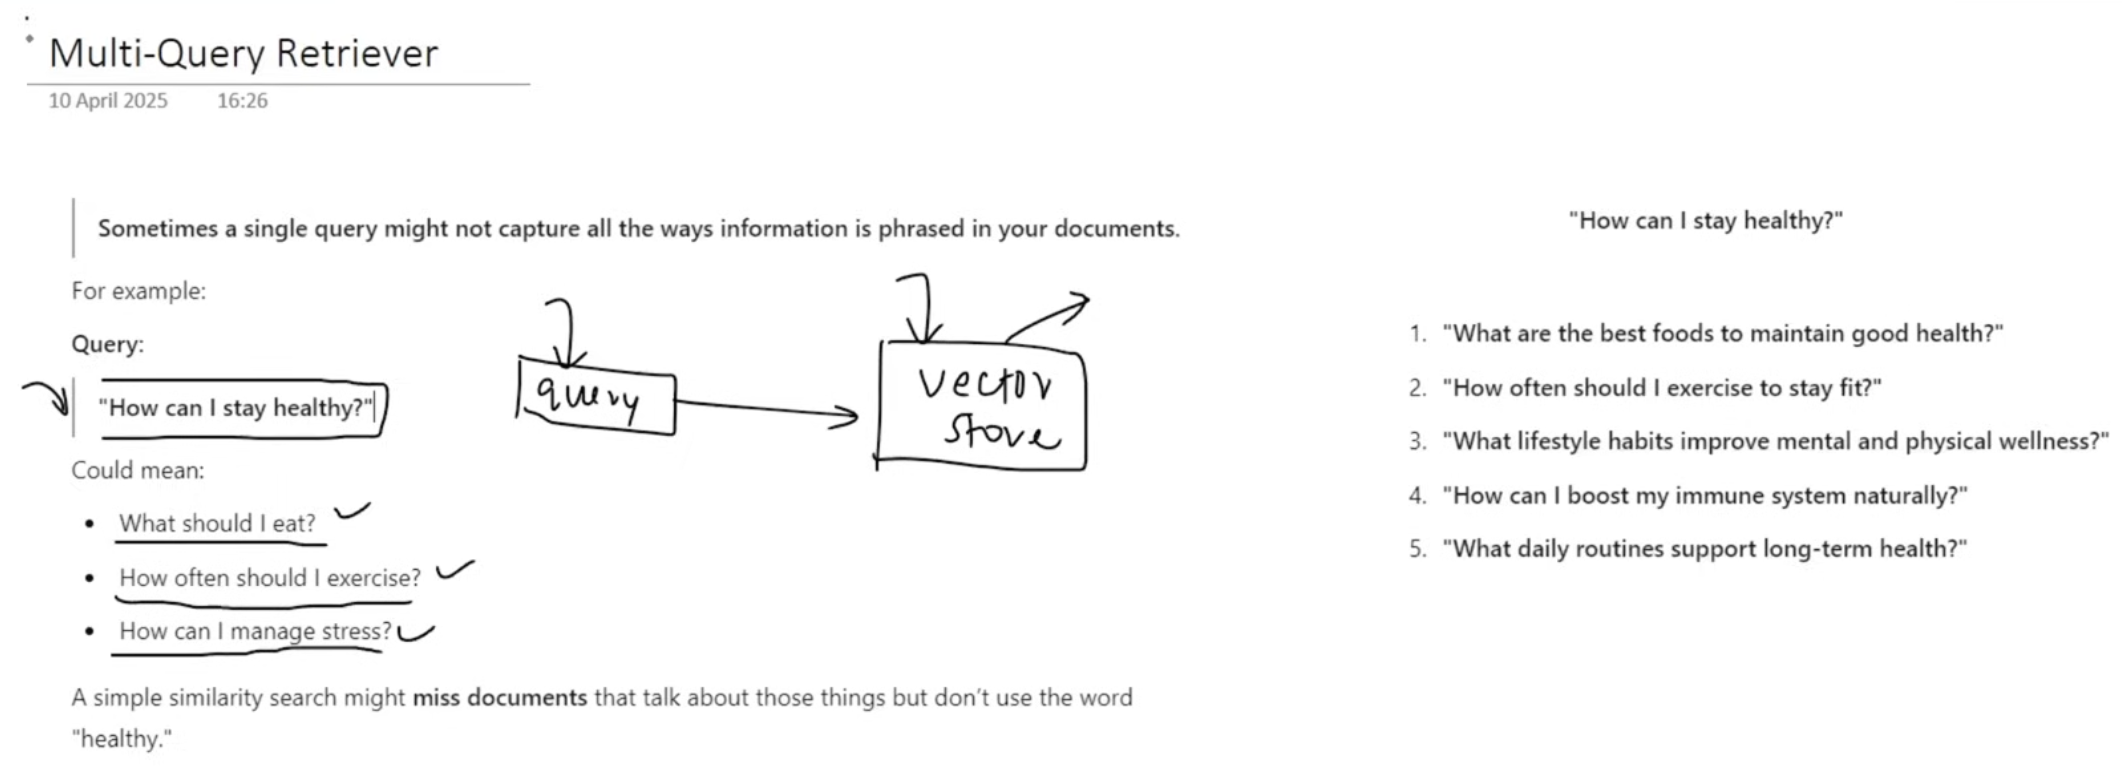

In [30]:
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document
from langchain.retrievers.multi_query import MultiQueryRetriever
from langchain_ollama import OllamaLLM

In [24]:
# Relevant health & wellness documents
all_docs = [
    Document(page_content="Regular walking boosts heart health and can reduce symptoms of depression.", metadata={"source": "H1"}),
    Document(page_content="Consuming leafy greens and fruits helps detox the body and improve longevity.", metadata={"source": "H2"}),
    Document(page_content="Deep sleep is crucial for cellular repair and emotional regulation.", metadata={"source": "H3"}),
    Document(page_content="Mindfulness and controlled breathing lower cortisol and improve mental clarity.", metadata={"source": "H4"}),
    Document(page_content="Drinking sufficient water throughout the day helps maintain metabolism and energy.", metadata={"source": "H5"}),
    Document(page_content="The solar energy system in modern homes helps balance electricity demand.", metadata={"source": "I1"}),
    Document(page_content="Python balances readability with power, making it a popular system design language.", metadata={"source": "I2"}),
    Document(page_content="Photosynthesis enables plants to produce energy by converting sunlight.", metadata={"source": "I3"}),
    Document(page_content="The 2022 FIFA World Cup was held in Qatar and drew global energy and excitement.", metadata={"source": "I4"}),
    Document(page_content="Black holes bend spacetime and store immense gravitational energy.", metadata={"source": "I5"}),
]

In [39]:
embedding_model = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

# Create FAISS vector store
vectorstore = FAISS.from_documents(documents=all_docs, embedding=embedding_model)

In [40]:
# Create retrievers
similarity_retriever = vectorstore.as_retriever(search_type="similarity", search_kwargs={"k": 5})

In [41]:
multiquery_retriever = MultiQueryRetriever.from_llm(
    retriever=vectorstore.as_retriever(search_kwargs={"k": 5}),
    llm=OllamaLLM(model="llama3.2")
)

In [42]:
# Query
query = "How to improve energy levels and maintain balance?"

In [43]:
# Retrieve results
similarity_results = similarity_retriever.invoke(query)
multiquery_results= multiquery_retriever.invoke(query)

In [44]:
for i, doc in enumerate(similarity_results):
    print(f"--- Result {i+1} ---")
    print(doc.page_content)
    print("\n")

print("*"*100)

for i, doc in enumerate(multiquery_results):
    print(f"\n--- Result {i+1} ---")
    print(doc.page_content)

--- Result 1 ---
Drinking sufficient water throughout the day helps maintain metabolism and energy.


--- Result 2 ---
The solar energy system in modern homes helps balance electricity demand.


--- Result 3 ---
Consuming leafy greens and fruits helps detox the body and improve longevity.


--- Result 4 ---
Mindfulness and controlled breathing lower cortisol and improve mental clarity.


--- Result 5 ---
Photosynthesis enables plants to produce energy by converting sunlight.


****************************************************************************************************

--- Result 1 ---
Black holes bend spacetime and store immense gravitational energy.

--- Result 2 ---
Python balances readability with power, making it a popular system design language.

--- Result 3 ---
Photosynthesis enables plants to produce energy by converting sunlight.

--- Result 4 ---
Consuming leafy greens and fruits helps detox the body and improve longevity.

--- Result 5 ---
Deep sleep is crucial for 

<h1 style="color:rgb(255, 98, 0);">5. Contextual Compression Retriever</h1>

![Screenshot 2025-04-24 at 2.50.38 PM.png](<attachment:Screenshot 2025-04-24 at 2.50.38 PM.png>)
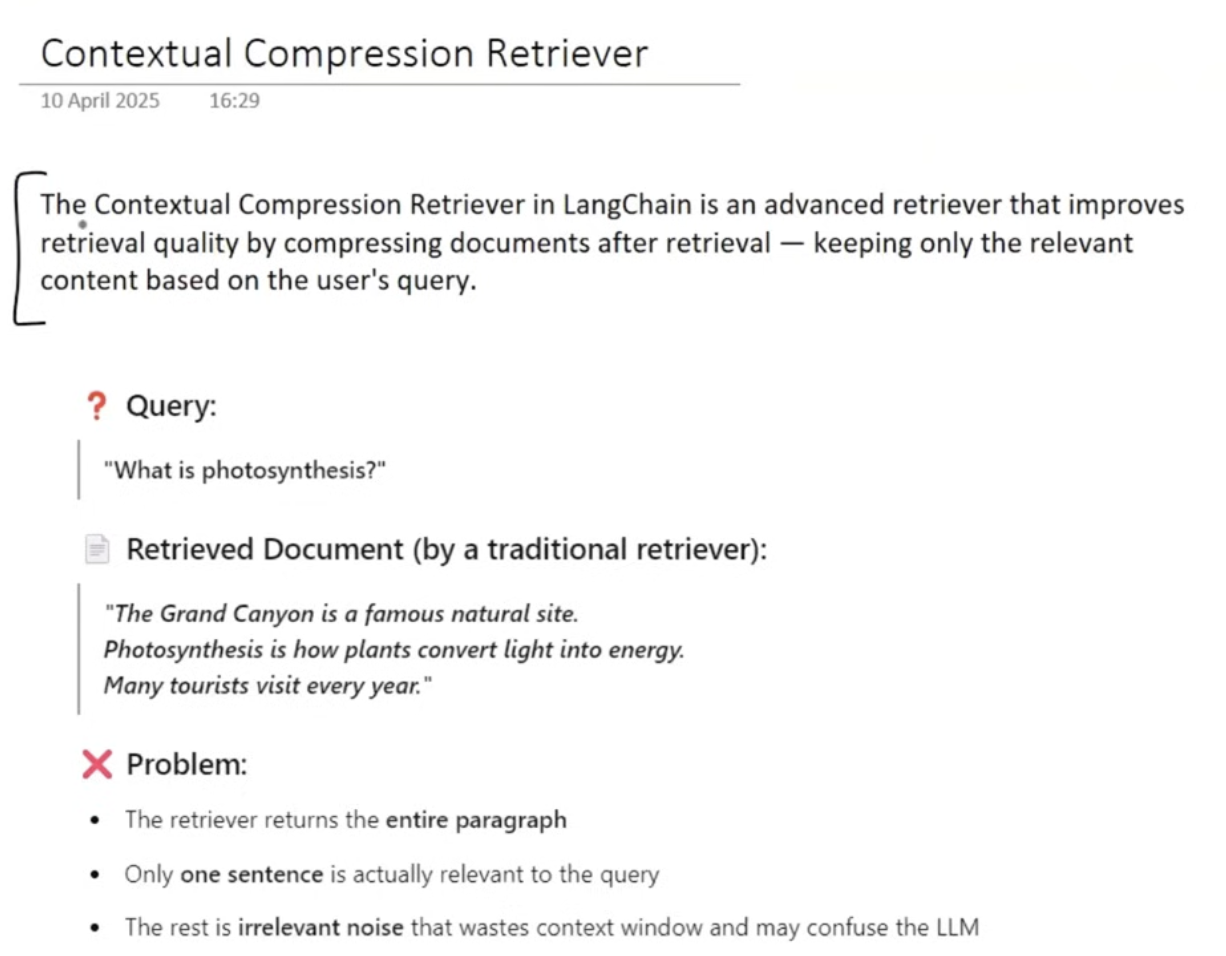

![Screenshot 2025-04-24 at 3.10.16 PM.png](<attachment:Screenshot 2025-04-24 at 3.10.16 PM.png>)
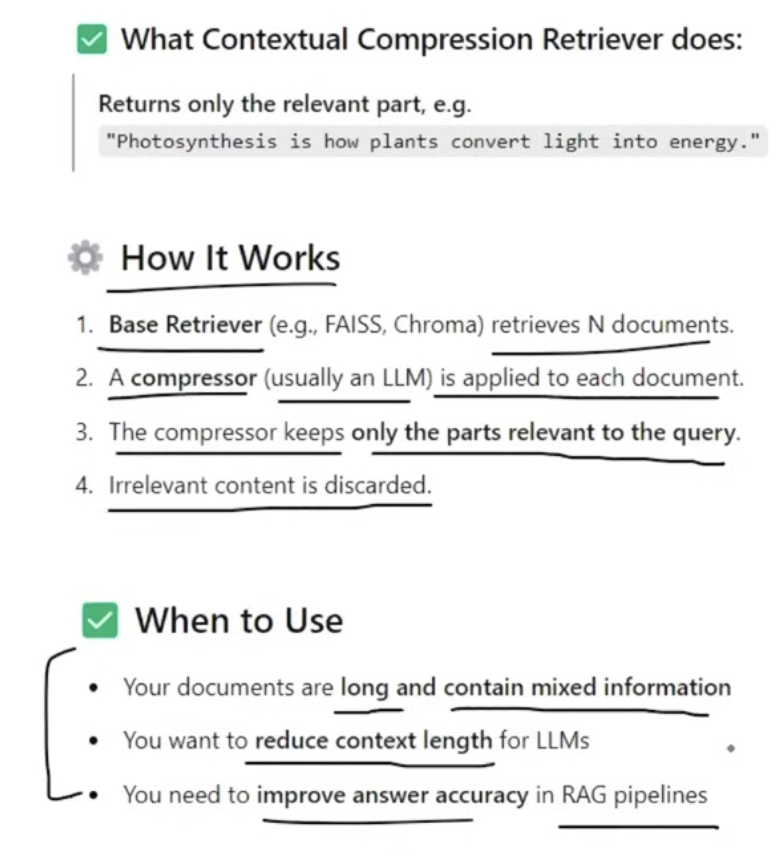

In [49]:
from langchain_community.vectorstores import FAISS
from langchain.retrievers.contextual_compression import ContextualCompressionRetriever
from langchain.retrievers.document_compressors import LLMChainExtractor
from langchain_core.documents import Document
from langchain_ollama import OllamaLLM

In [50]:
# Recreate the document objects from the previous data
docs = [
    Document(page_content=(
        """The Grand Canyon is one of the most visited natural wonders in the world.
        Photosynthesis is the process by which green plants convert sunlight into energy.
        Millions of tourists travel to see it every year. The rocks date back millions of years."""
    ), metadata={"source": "Doc1"}),

    Document(page_content=(
        """In medieval Europe, castles were built primarily for defense.
        The chlorophyll in plant cells captures sunlight during photosynthesis.
        Knights wore armor made of metal. Siege weapons were often used to breach castle walls."""
    ), metadata={"source": "Doc2"}),

    Document(page_content=(
        """Basketball was invented by Dr. James Naismith in the late 19th century.
        It was originally played with a soccer ball and peach baskets. NBA is now a global league."""
    ), metadata={"source": "Doc3"}),

    Document(page_content=(
        """The history of cinema began in the late 1800s. Silent films were the earliest form.
        Thomas Edison was among the pioneers. Photosynthesis does not occur in animal cells.
        Modern filmmaking involves complex CGI and sound design."""
    ), metadata={"source": "Doc4"})
]

In [52]:
# Create a FAISS vector store from the documents
embedding_model = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")
vectorstore = FAISS.from_documents(docs, embedding_model)

In [53]:
base_retriever = vectorstore.as_retriever(search_kwargs={"k": 5})

In [55]:
# Set up the compressor using an LLM
llm=OllamaLLM(model="llama3.2")
compressor = LLMChainExtractor.from_llm(llm)

In [56]:
# Create the contextual compression retriever
compression_retriever = ContextualCompressionRetriever(
    base_retriever=base_retriever,
    base_compressor=compressor
)

In [57]:
# Query the retriever
query = "What is photosynthesis?"
compressed_results = compression_retriever.invoke(query)

In [58]:
for i, doc in enumerate(compressed_results):
    print(f"\n--- Result {i+1} ---")
    print(doc.page_content)


--- Result 1 ---
> Photosynthesis is the process by which green plants convert sunlight into energy.

--- Result 2 ---
The extracted relevant part is:

The chlorophyll in plant cells captures sunlight during photosynthesis.
